In [1]:
# Libraries & Imports
import json
import platform
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
HORIZONS = [1, 3, 7]
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')
REPORTS_DIR = Path('../reports')
MODELS_DIR = Path('../models')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# SHAP is used to verify the models. Import it if present, if not, the notebook stays runnable by falling back to permutation importance.
try:
    import shap
    HAS_SHAP = True
    print(f'shap {shap.__version__} available - using SHAP for feature attribution.')
except ImportError:
    HAS_SHAP = False
    print('shap not installed - will fall back to permutation importance.')

print('All libraries loaded.')

shap 0.52.0 available - using SHAP for feature attribution.
All libraries loaded.


### Results

**Goal of this notebook:** take the model and horizon candidates that were selected in `03_modelling.ipynb` on the 2024 validation year, retrain them on all pre-test data (2016-2024), and evaluate them **once** on the held-out sets - the 2025 calendar year (primary, headline metrics) and the Jan-Apr 2026 recency window (reported separately).

This notebook answers:
1. Do the validation-selected models hold their skill on data from a year they never saw, or was the validation performance optimistic? (the **generalisation gap**)
2. How large is the skill over the persistence and climatology baselines on truly held-out data, per horizon?
3. Does the unified model still generalise **per city** on the test year, including the alpine Yundola and the coastal stations?
4. **Which features actually drive the forecasts** (SHAP), and do they match the physical predictors the EDA and feature-engineering notebooks bet on (pressure, dew point, soil temperature, the autoregressive lags)?
5. What would it take to run this operationally - live data, retraining cadence, a forecast UI - and what are the honest limitations of this project approach?

#### The One-shot Test Discipline

The test sets were created in notebook 02 and deliberately left unopened through notebook 03. Every model family, hyperparameter and decision threshold was fixed only on 2024 validation data. The reasoning follows Géron's warning that each time each time a test set is used to *make a choice*, it stops being an unbiased estimate of generalisation error and the reported skill drifts upward [2]. So here the test data is used exactly once, for measurement only - no tuning, no threshold re-fitting, no model swapping based on what the results are.


#### Pre-registered Candidates Carried Over From Notebook 03

These selections were made on **validation only** and are now frozen. The chosen model at each horizon is the primary model and the others are retrained alongside it purely so the test table mirrors the validation table and the gap is visualized uniformly rather than cherry-picked.

**Temperature regression (primary metric: RMSE)**

| Horizon | Champion | Why it won on validation |
|---|---|---|
| 1-day | HistGradientBoosting | Best val RMSE; today's synoptic state is strongly informative at short range. |
| 3-day | Ridge | Trees start fitting noise as the signal weakens; shrinkage generalises better. |
| 7-day | Ridge | Same bias-variance argument, more pronounced at long range. |

**Rain classification (primary metric: PR-AUC; decision threshold fixed on validation)**

| Horizon | Champion | Why it won on validation |
|---|---|---|
| 1-day | HistGradientBoosting | Best PR-AUC / AUC-ROC; captures humidity x pressure x cloud conjunctions. |
| 3-day | RandomForest | Edges ahead on PR-AUC where the signal is weak. |
| 7-day | RandomForest | Same; all three families sit within noise of each other here. |

The hyperparameters below are exactly the ones tuned on validation in notebook 03. The rain decision thresholds are reloaded from the notebook-03 run log, so no threshold is fit on test.

In [2]:
print('Environment (recorded for reproducibility):')
print(f' -python: {sys.version.split()[0]} ({platform.system()})')
print(f' -numpy: {np.__version__}')
print(f' -pandas: {pd.__version__}')
print(f' -scikit-learn: {sklearn.__version__}')
print(f' -random_state: {RANDOM_STATE}')

# Validation-tuned hyperparameters carried over from notebook 03.
RIDGE_PARAMS = {'alpha': 0.1}
HGB_REG_PARAMS = {'learning_rate': 0.03, 'max_leaf_nodes': 31,
                  'min_samples_leaf': 20, 'l2_regularization': 0.0, 'max_iter': 400}
RF_REG_PARAMS = {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 5}

LOGIT_PARAMS = {'C': 1.0, 'max_iter': 1000}
RF_CLF_PARAMS = {'n_estimators': 300, 'max_depth': 16, 'min_samples_leaf': 5}
HGB_CLF_PARAMS = {'learning_rate': 0.03, 'max_leaf_nodes': 31,
                  'min_samples_leaf': 30, 'l2_regularization': 1.0, 'max_iter': 400}

# Pre-registered champions (chosen on validation in notebook 03)
TEMP_SELECTION = {1: 'HistGradientBoosting', 3: 'Ridge', 7: 'Ridge'}
RAIN_SELECTION = {1: 'HistGradientBoosting', 3: 'RandomForest', 7: 'RandomForest'}

print('\nPre-registered models:')
print(' temperature:', TEMP_SELECTION)
print(' rain:', RAIN_SELECTION)

Environment (recorded for reproducibility):
 -python: 3.13.9 (Windows)
 -numpy: 2.3.5
 -pandas: 2.3.3
 -scikit-learn: 1.7.2
 -random_state: 42

Pre-registered models:
 temperature: {1: 'HistGradientBoosting', 3: 'Ridge', 7: 'Ridge'}
 rain: {1: 'HistGradientBoosting', 3: 'RandomForest', 7: 'RandomForest'}


#### Loading Data

Next step is to load all four splits - including the test parquets that were not used in notebook 03. The fitted `StandardScaler` and the feature/target column lists come from notebook 02 unchanged, so the test data goes through the identical preprocessing the models were trained under. The notebook-03 run log and selection tables are also reloaded: the validation numbers (for the generalisation-gap comparison) and the validation-tuned rain thresholds both come from there.

In [3]:
train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
val = pd.read_parquet(PROCESSED_DIR / 'val.parquet')
test_2025 = pd.read_parquet(PROCESSED_DIR / 'test_2025.parquet')
test_2026 = pd.read_parquet(PROCESSED_DIR / 'test_2026.parquet')
scaler = joblib.load(PROCESSED_DIR / 'scaler.joblib')

with open(PROCESSED_DIR / 'feature_columns.json', encoding='utf-8') as f:
    col_spec = json.load(f)
feature_cols = col_spec['feature_cols']
scaled_cols = col_spec['scaled_cols']

# Notebook-03 outputs: full run log + the two validation selection tables.
val_results = pd.read_csv(REPORTS_DIR / 'modelling_results.csv')
sel_temp = pd.read_csv(REPORTS_DIR / 'selection_temperature.csv')
sel_rain = pd.read_csv(REPORTS_DIR / 'selection_rain.csv')

for name, frame in [('train', train), ('val', val), ('test_2025', test_2025), ('test_2026', test_2026)]:
    print(f'{name:10s}: {frame.shape} - {frame.date.min().date()} - {frame.date.max().date()}')
print(f'\nfeatures: {len(feature_cols)};  targets: {col_spec["target_cols"]}')

train     : (29150, 84) - 2016-01-08 - 2023-12-31
val       : (3660, 84) - 2024-01-01 - 2024-12-31
test_2025 : (3650, 84) - 2025-01-01 - 2025-12-31
test_2026 : (1140, 84) - 2026-01-01 - 2026-04-24

features: 76;  targets: ['tavg_target_1d', 'rain_target_1d', 'tavg_target_3d', 'rain_target_3d', 'tavg_target_7d', 'rain_target_7d']


#### Building the Train and Validation Fitting Set

For the final models, training uses the pooled 2016–2024 set (train + validation). Validation has already served its purpose (model and threshold selection), so retaining it separately offers no further benefit. Pooling maximizes pre-test history for the frozen final fit, consistent with standard best practice. 

The train/test boundary is unchanged: test data still begins strictly after 2024, preserving the no-leakage guarantee.Baseline values are converted back to physical units by inverting the stored train-fit scaler on the relevant column (`raw = scaled * scale_ + mean_`). Climatology normals are computed over the same pooled 2016–2024 period and never from test data.

In [4]:
trainval = pd.concat([train, val], ignore_index=True)

def inverse_col(frame, col):
    "Recover a single column in original units from the train-fit StandardScaler."
    idx = scaled_cols.index(col)
    return frame[col].to_numpy() * scaler.scale_[idx] + scaler.mean_[idx]

for frame in (trainval, test_2025, test_2026):
    frame['tavg_now'] = inverse_col(frame, 'tavg')
    frame['rain_now'] = inverse_col(frame, 'rain')

X_trainval = trainval[feature_cols]
X_test_2025 = test_2025[feature_cols]
X_test_2026 = test_2026[feature_cols]

print(f'Combined fitting set (train+val): {trainval.shape}  '
      f'{trainval.date.min().date()} - {trainval.date.max().date()}')

# Leakage guards
order_2025_ok = trainval['date'].max() < test_2025['date'].min()
order_2026_ok = test_2025['date'].max() < test_2026['date'].min()
trainval_nan = int(trainval[feature_cols].isna().sum().sum())
test2025_nan = int(test_2025[feature_cols].isna().sum().sum())

print('\nLeakage / integrity guards:')
print(f"  train+val ends {trainval['date'].max().date()} < 2025 test starts "
      f"{test_2025['date'].min().date()} - {order_2025_ok}")
print(f"  2025 test ends {test_2025['date'].max().date()} < 2026 recency starts "
      f"{test_2026['date'].min().date()} - {order_2026_ok}")
print(f"  NaNs in train+val features: {trainval_nan} - {trainval_nan == 0}")
print(f"  NaNs in 2025 test features: {test2025_nan} - {test2025_nan == 0}")

assert order_2025_ok, 'train+val must precede 2025 test'
assert order_2026_ok, '2025 test must precede 2026 recency'
assert trainval_nan == 0, 'no NaNs allowed in fitting features'
assert test2025_nan == 0, 'no NaNs allowed in 2025 features'
print('All guards passed.')

# Climatology lookup fit on pre-test years only
clim_table = (trainval.assign(doy=trainval.date.dt.dayofyear)
              .groupby(['city', 'doy'])['tavg_now'].mean())
city_mean_tavg = trainval.groupby('city')['tavg_now'].mean()

def climatology_predict(frame, horizon):
    "Seasonal-normal forecast for the target day (date + horizon), per city."
    target_doy = (frame['date'] + pd.Timedelta(days=horizon)).dt.dayofyear
    keys = zip(frame['city'].to_numpy(), target_doy.to_numpy())
    return np.array([clim_table.get(k, city_mean_tavg[k[0]]) for k in keys])

print(f'Climatology table: {clim_table.shape[0]} (city, day-of-year) cells from 2016-2024')

Combined fitting set (train+val): (32810, 86)  2016-01-08 - 2024-12-31

Leakage / integrity guards:
  train+val ends 2024-12-31 < 2025 test starts 2025-01-01 - True
  2025 test ends 2025-12-31 < 2026 recency starts 2026-01-01 - True
  NaNs in train+val features: 0 - True
  NaNs in 2025 test features: 0 - True
All guards passed.
Climatology table: 3660 (city, day-of-year) cells from 2016-2024


In [5]:
def make_reg(name):
    "Construct a fresh regressor with its validation-tuned hyperparameters."
    if name == 'Ridge':
        return Ridge(**RIDGE_PARAMS)
    if name == 'RandomForest':
        return RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE, **RF_REG_PARAMS)
    if name == 'HistGradientBoosting':
        return HistGradientBoostingRegressor(random_state=RANDOM_STATE, **HGB_REG_PARAMS)
    raise ValueError(name)

def regression_metrics(y_true, pred, persist_mae, clim_mae):
    "RMSE, MAE and skill over both reference baselines."
    mae = mean_absolute_error(y_true, pred)
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, pred)),
        'mae': mae,
        'skill_vs_persist': 1 - mae / persist_mae,
        'skill_vs_clim': 1 - mae / clim_mae,
    }

reg_families = ['Ridge', 'RandomForest', 'HistGradientBoosting']
reg_rows = []
final_reg_models = {} #(selected model name, horizon): fitted model, for SHAP/saving
reg_test_pred = {}  # (model, horizon, split): predictions

print('Retraining temperature models on 2016-2024 and scoring on held-out sets...\n')
for h in HORIZONS:
    y_tv = trainval[f'tavg_target_{h}d'].to_numpy()
    targets = {'2025': (test_2025, test_2025[f'tavg_target_{h}d'].to_numpy()),
               '2026': (test_2026, test_2026[f'tavg_target_{h}d'].to_numpy())}

    # Baselines on each test split
    for split, (frame, y_true) in targets.items():
        persist = frame['tavg_now'].to_numpy()
        clim = climatology_predict(frame, h)
        p_mae = mean_absolute_error(y_true, persist)
        c_mae = mean_absolute_error(y_true, clim)
        for bname, bpred, smae in [('Persistence', persist, p_mae), ('Climatology', clim, c_mae)]:
            m = regression_metrics(y_true, bpred, p_mae, c_mae)
            reg_rows.append({'split': split, 'horizon': h, 'model': bname, **m})

    # Learned families
    for name in reg_families:
        t0 = time.time()
        model = make_reg(name).fit(X_trainval, y_tv)
        fit_sec = time.time() - t0
        for split, (frame, y_true) in targets.items():
            X = frame[feature_cols]
            pred = model.predict(X)
            reg_test_pred[(name, h, split)] = pred
            persist = frame['tavg_now'].to_numpy()
            clim = climatology_predict(frame, h)
            m = regression_metrics(y_true, pred, mean_absolute_error(y_true, persist), mean_absolute_error(y_true, clim))
            reg_rows.append({'split': split, 'horizon': h, 'model': name, **m})
        if name == TEMP_SELECTION[h]:
            final_reg_models[(name, h)] = model
            print(f'h={h}d selected model: {name:20s} fit {fit_sec:4.1f}s')

reg_results = pd.DataFrame(reg_rows)
print('\nTemperature evaluation complete.')

Retraining temperature models on 2016-2024 and scoring on held-out sets...

h=1d selected model: HistGradientBoosting fit  6.6s
h=3d selected model: Ridge                fit  0.0s
h=7d selected model: Ridge                fit  0.0s

Temperature evaluation complete.


In [6]:
order = ['Persistence', 'Climatology', 'Ridge', 'RandomForest', 'HistGradientBoosting']
t2025 = reg_results[reg_results.split == '2025']

print('TEST 2025 - RMSE (degrees C) by model x horizon:')
print(t2025.pivot_table(index='model', columns='horizon', values='rmse').reindex(order).round(3).to_string())
print('\nTEST 2025 - MAE (degrees C):')
print(t2025.pivot_table(index='model', columns='horizon', values='mae').reindex(order).round(3).to_string())
print('\nTEST 2025 - Skill vs persistence (MAE-based; >0 beats persistence):')
print(t2025.pivot_table(index='model', columns='horizon', values='skill_vs_persist').reindex(order[1:]).round(3).to_string())
print('\nTEST 2025 - Skill vs climatology (>0 beats the seasonal normal):')
print(t2025.pivot_table(index='model', columns='horizon', values='skill_vs_clim').reindex(order[2:]).round(3).to_string())

print('\n\nHeadline RMSE on 2025:')
for h in HORIZONS:
    selected = TEMP_SELECTION[h]
    r = t2025[(t2025.horizon == h) & (t2025.model == selected)].iloc[0]
    print(f'  {h}-day: {selected:20s} RMSE={r.rmse:.3f}  MAE={r.mae:.3f}  '
          f'skill(persist)={r.skill_vs_persist:+.2f}  skill(clim)={r.skill_vs_clim:+.2f}')

TEST 2025 - RMSE (degrees C) by model x horizon:
horizon                   1      3      7
model                                    
Persistence           1.918  3.631  4.689
Climatology           3.703  3.710  3.741
Ridge                 1.675  3.057  3.520
RandomForest          1.708  3.248  3.994
HistGradientBoosting  1.677  3.232  3.857

TEST 2025 - MAE (degrees C):
horizon                   1      3      7
model                                    
Persistence           1.445  2.821  3.647
Climatology           2.847  2.857  2.878
Ridge                 1.265  2.332  2.671
RandomForest          1.278  2.493  2.963
HistGradientBoosting  1.250  2.476  2.872

TEST 2025 - Skill vs persistence (MAE-based; >0 beats persistence):
horizon                   1      3      7
model                                    
Climatology          -0.970 -0.013  0.211
Ridge                 0.125  0.173  0.268
RandomForest          0.116  0.116  0.188
HistGradientBoosting  0.135  0.122  0.213

TEST 2025 -

At 1-day, all three models beat both baselines: Ridge and HistGradientBoosting are essentially tied for lowest RMSE (1.675 / 1.677°C). As horizon increases, skill vs. climatology falls (Ridge and RandomForest), while skill vs. persistence rises, consistent with persistence's RMSE growing fastest and climatology's staying near the same. 

Ridge has the lowest RMSE at 3-day (3.057) and 7-day (3.520), overtaking the tree-based models as horizon lengthens. All models beat persistence at every horizon, but by 7-day only Ridge and HistGradientBoosting still beat climatology.

#### Generalisation gap: validation (2024) vs test (2025)
For each selected model the 2024 validation RMSE (chosen-on number, from notebook 03) is copmared next to the 2025 test RMSE (not computed yet). A small gap means the validation selection was trustworthy and the model is not overfit to 2024, contrary a large positive jump would mean the validation result was optimistic and further decision must be made.

Temperature generalisation gap (RMSE, degrees C):
 horizon             selected  val_2024_rmse  test_2025_rmse   gap
       1 HistGradientBoosting          1.642           1.677 0.036
       3                Ridge          2.912           3.057 0.145
       7                Ridge          3.257           3.520 0.263


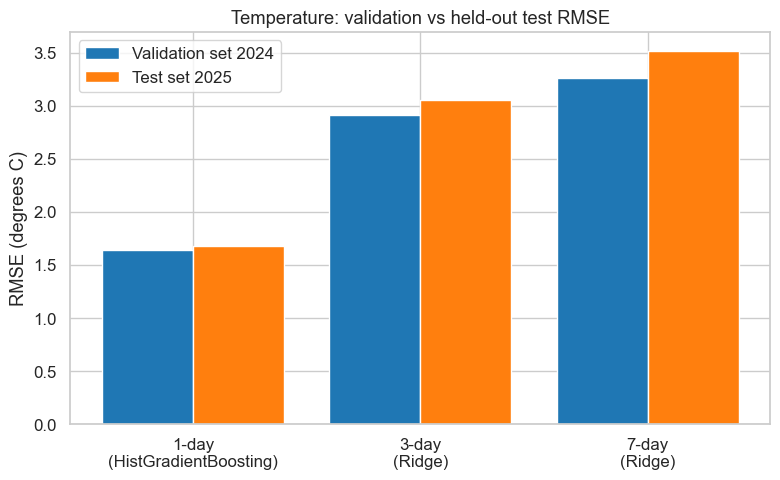

Saved: test_temperature_val_vs_test.png


In [7]:
gap_rows = []
for h in HORIZONS:
    selected = TEMP_SELECTION[h]
    val_rmse = sel_temp[sel_temp.horizon == h].iloc[0]['rmse']
    test_rmse = t2025[(t2025.horizon == h) & (t2025.model == selected)].iloc[0]['rmse']
    gap_rows.append({'horizon': h, 'selected': selected,
                     'val_2024_rmse': val_rmse, 'test_2025_rmse': test_rmse,
                     'gap': test_rmse - val_rmse})
gap_temp = pd.DataFrame(gap_rows)
print('Temperature generalisation gap (RMSE, degrees C):')
print(gap_temp.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(HORIZONS))
ax.bar(x - 0.2, gap_temp['val_2024_rmse'], 0.4, label='Validation set 2024')
ax.bar(x + 0.2, gap_temp['test_2025_rmse'], 0.4, label='Test set 2025')
ax.set_xticks(x)
ax.set_xticklabels([f'{h}-day\n({c})' for h, c in zip(gap_temp.horizon, gap_temp.selected)])
ax.set_ylabel('RMSE (degrees C)')
ax.set_title('Temperature: validation vs held-out test RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'test_temperature_val_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_temperature_val_vs_test.png')

#### What the figure shows:

Temperature forecasting RMSE rises with horizon and degrades slightly from validation set (2024) to test set (2025). At the 1-day horizon, HistGradientBoosting is the selected model with a test RMSE of 1.677 degrees C and a near-negligible generalisation gap of 0.036 degrees C. For the 3-day and 7-day horizons, Ridge is the selected model, reaching test RMSEs of 3.057 and 3.520 degrees C respectively, with the gap widening slightly from 0.145 to 0.263 degrees C as the horizon lengthens. All three gaps are small (about 2-7% of RMSE) and well within year-to-year climate variability, indicating that performance generalises well from the 2024 validation year to the held-out 2025 test year, with no evidence of degradation at longer horizons.

#### Predicted vs actual and the error-vs-horizon decay (2025)

Two diagnostics on the held-out year are ran: the 1-day selected model's predicted-vs-actual scatter (how tight the forecast is around the 1:1 line across the full -10 to +30 C range), and the RMSE-vs-horizon curve for the selected models against both baselines (the central "skill decays with lead time" result, now on unseen data).

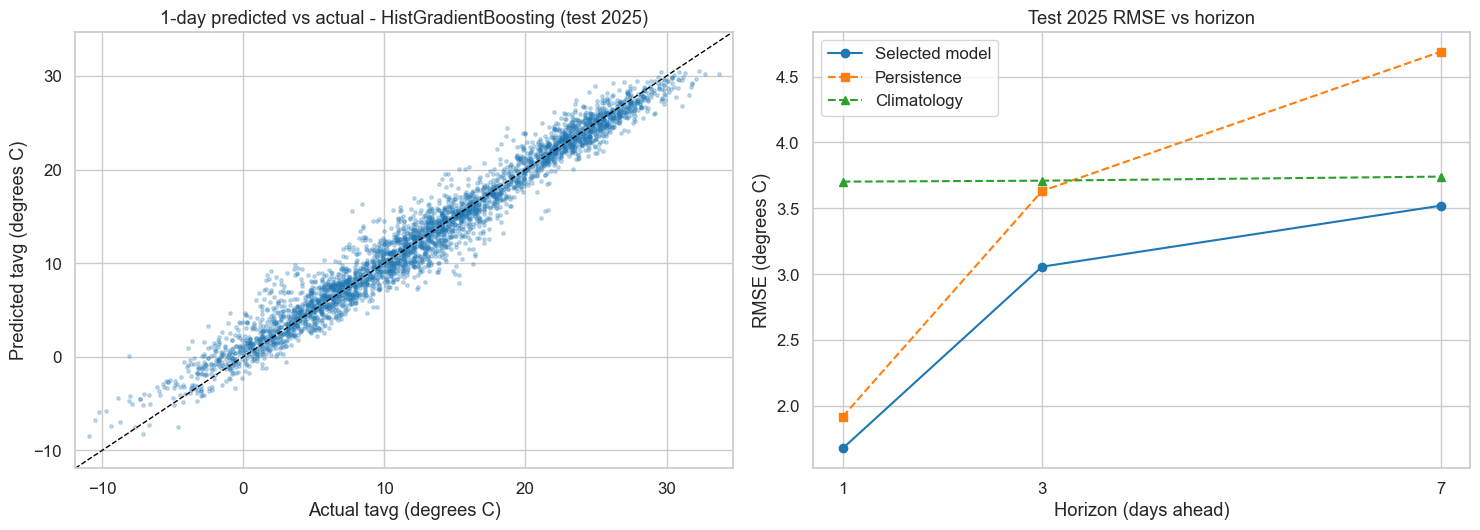

Saved: test_temperature_diagnostics.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Predicted vs actual for the 1-day selected model on 2025
selected1 = TEMP_SELECTION[1]
y_true_1d = test_2025['tavg_target_1d'].to_numpy()
pred_1d = reg_test_pred[(selected1, 1, '2025')]
lims = [min(y_true_1d.min(), pred_1d.min()) - 1, max(y_true_1d.max(), pred_1d.max()) + 1]
axes[0].scatter(y_true_1d, pred_1d, s=6, alpha=0.25, color='C0')
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual tavg (degrees C)')
axes[0].set_ylabel('Predicted tavg (degrees C)')
axes[0].set_title(f'1-day predicted vs actual - {selected1} (test 2025)')

# RMSE vs horizon: selected vs baselines
selected_rmse = [t2025[(t2025.horizon == h) & (t2025.model == TEMP_SELECTION[h])].iloc[0]['rmse'] for h in HORIZONS]
persist_rmse = [t2025[(t2025.horizon == h) & (t2025.model == 'Persistence')].iloc[0]['rmse'] for h in HORIZONS]
clim_rmse = [t2025[(t2025.horizon == h) & (t2025.model == 'Climatology')].iloc[0]['rmse'] for h in HORIZONS]
axes[1].plot(HORIZONS, selected_rmse, 'o-', label='Selected model')
axes[1].plot(HORIZONS, persist_rmse, 's--', label='Persistence')
axes[1].plot(HORIZONS, clim_rmse, '^--', label='Climatology')
axes[1].set_xticks(HORIZONS)
axes[1].set_xlabel('Horizon (days ahead)')
axes[1].set_ylabel('RMSE (degrees C)')
axes[1].set_title('Test 2025 RMSE vs horizon')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'test_temperature_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_temperature_diagnostics.png')

#### What the figure shows:

The left panel shows the 1-day HistGradientBoosting forecasts tracking the 1:1 line across the full -10 to +30 C range on held-out 2025 data (RMSE = 1.68 C), with scatter widening only slightly at the temperature extremes. The right panel shows the central "skill decays with lead time" result on unseen data: the selected models' RMSE rises from 1.68 C at 1 day to 3.06 C at 3 days and 3.52 C at 7 days, staying below persistence at every horizon (1.92 / 3.63 / 4.69 C). The advantage over persistence grows with lead time, while flat climatology (~3.7 C) is only overtaken from the 3-day horizon onward - so the model adds genuine skill at every range, but its edge over the seasonal normal is concentrated at short-to-medium lead times.

#### Per-city Temperature Skill on the Held-out Test Set (2025)

Per-city test-2025 RMSE (selected model per horizon, degrees C):
horizon             1      3      7
city                               
vidin           1.684  2.970  3.298
kardzhali       1.476  2.743  3.305
varna           1.619  2.811  3.319
sofia           1.639  3.020  3.439
burgas          1.588  2.913  3.456
haskovo         1.604  2.925  3.485
yundola         1.602  3.051  3.582
veliko_tarnovo  1.834  3.320  3.675
pleven          1.801  3.308  3.698
ruse            1.882  3.429  3.893


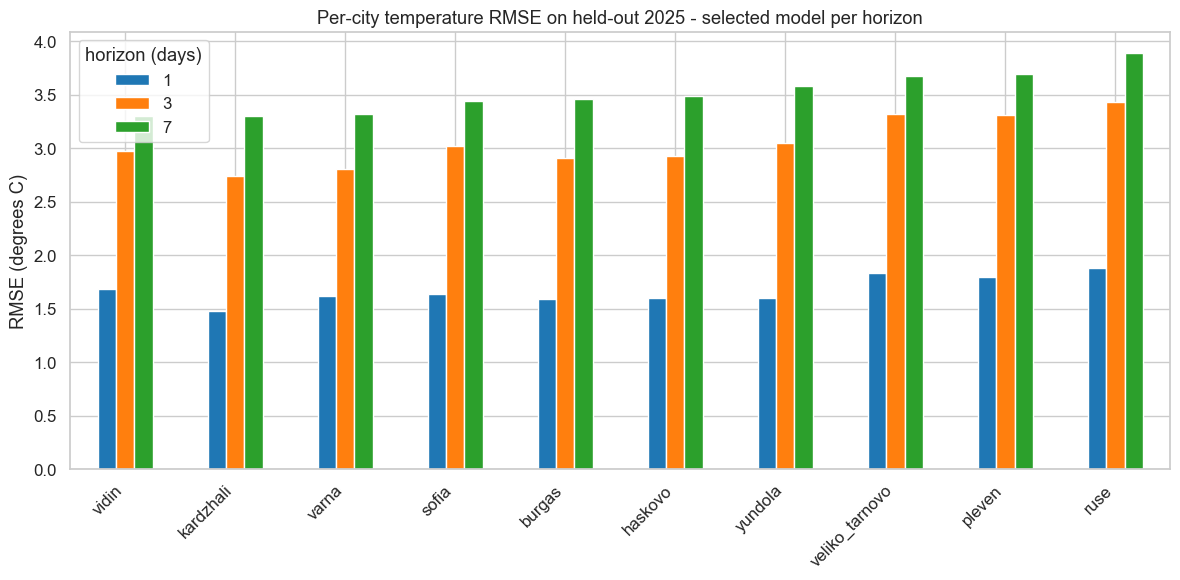

Saved: test_per_city_rmse.png


In [10]:
rows = []
for h in HORIZONS:
    selected = TEMP_SELECTION[h]
    pred = reg_test_pred[(selected, h, '2025')]
    y_true = test_2025[f'tavg_target_{h}d'].to_numpy()
    tmp = pd.DataFrame({'city': test_2025['city'].to_numpy(), 'err': y_true - pred})
    rmse_city = tmp.groupby('city')['err'].apply(lambda e: np.sqrt((e ** 2).mean()))
    for city, v in rmse_city.items():
        rows.append({'city': city, 'horizon': h, 'rmse': v})

per_city_temp = pd.DataFrame(rows).pivot_table(index='city', columns='horizon', values='rmse').sort_values(7)
print('Per-city test-2025 RMSE (selected model per horizon, degrees C):')
print(per_city_temp.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
per_city_temp.plot(kind='bar', ax=ax)
ax.set_title('Per-city temperature RMSE on held-out 2025 - selected model per horizon')
ax.set_ylabel('RMSE (degrees C)'); ax.set_xlabel('')
ax.legend(title='horizon (days)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'test_per_city_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_per_city_rmse.png')

#### What the figure shows:

Looking at the chart above and comparing it against the per-city validation RMSE from notebook-3 (`regression_per_city_rmse.png`). Both use the same models - HistGradientBoosting at 1-day, Ridge at 3 and 7-day - and the same metric, so they are comparable. 

![Per-city validation RMSE from notebook-3](../reports/figures/regression_per_city_rmse.png)


Two results stand out at the 7-day stress horizon:

- **The Danube-Valey & Subcontinental region.** Ruse, Pleven and Veliko Tarnovo are the three weakest stations on validation and again on test data (7-day RMSE 3.68-3.89 C). Their difficulty is a stable climatological property of the Danube-valley / subcontinental interior, not a one-year artefact.
- **Yundola is the one station that did not generalise.** The alpine site (1213 m) was the *best* city on validation (2.79 C at 7-day) but drops to mid-pack on test (3.58 C) - a +0.79 C jump, by far the largest gap of any city. Its 2024 advantage was partly optimistic, exactly what a per-city gap check exists to surface.

Every other city moves by only +0.1 to +0.4 C from validation to test (Vidin even improves slightly), so the unified geographically-encoded model holds its skill across all 10 climate zones rather than overfitting the easy lowland stations - with Yundola the single case worth flagging.

### Final Rain Models: Retrain on 2016-2024, Evaluate once on test set 2025

The same retrain-and-evaluate-once procedure for the wet-day classifiers is now performed too. Two points of discipline carried from notebook 03:

- **Imbalance** is handled with inverse-frequency `sample_weight` (the one form that works identically for the logistic, forest and boosting models), not resampling.
- **Decision thresholds are frozen from validation.** Each classifier's F1-optimal threshold was chosen on 2024 in notebook 03 and is reloaded here from the run log. Tuning a threshold on test would be exactly the leakage the one-shot discipline forbids, so the stored validation thresholds are applied as-is.

Reported metrics are the imbalance-aware set: PR-AUC (headline, read against the ~0.40 base rate), AUC-ROC, F1 at the frozen threshold, and the Brier score for probability calibration.

In [12]:
from sklearn.utils.class_weight import compute_sample_weight

def make_clf(name):
    "Construct a fresh classifier with its validation-tuned hyperparameters."
    if name == 'LogisticRegression':
        return LogisticRegression(random_state=RANDOM_STATE, **LOGIT_PARAMS)
    if name == 'RandomForest':
        return RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE, **RF_CLF_PARAMS)
    if name == 'HistGradientBoosting':
        return HistGradientBoostingClassifier(random_state=RANDOM_STATE, **HGB_CLF_PARAMS)
    raise ValueError(name)

# Validation-tuned decision thresholds, reloaded from the notebook-03 run log.
thr_lookup = (val_results[val_results.task == 'rain']
              .dropna(subset=['best_threshold'])
              .set_index(['model', 'horizon'])['best_threshold'].to_dict())

def frozen_threshold(name, h):
    "Validation-optimal threshold from notebook 03; 0.5 if unavailable."
    return float(thr_lookup.get((name, h), 0.5))

clf_families = ['LogisticRegression', 'RandomForest', 'HistGradientBoosting']
clf_rows = []
final_clf_models = {} #(selected model name, horizon): fitted model
clf_test_proba = {} # (model, horizon, split): positive-class probabilities

print('Retraining rain models on 2016-2024 and scoring on held-out sets...\n')
for h in HORIZONS:
    y_tv = trainval[f'rain_target_{h}d'].to_numpy().astype(int)
    sw = compute_sample_weight('balanced', y_tv)
    targets = {'2025': (test_2025, test_2025[f'rain_target_{h}d'].to_numpy().astype(int)),
               '2026': (test_2026, test_2026[f'rain_target_{h}d'].to_numpy().astype(int))}

    # Baselines (per split)
    for split, (frame, y_true) in targets.items():
        base = y_true.mean()
        rp = (frame['rain_now'].to_numpy() > 0).astype(int)
        clf_rows.append({'split': split, 'horizon': h, 'model': 'MajorityClass',
                         'pr_auc': base, 'auc_roc': 0.5,
                         'f1': 0.0, 'threshold': 0.5,
                         'brier': brier_score_loss(y_true, np.full_like(y_true, y_tv.mean(), dtype=float))})
        clf_rows.append({'split': split, 'horizon': h, 'model': 'RainPersistence',
                         'pr_auc': average_precision_score(y_true, rp), 'auc_roc': roc_auc_score(y_true, rp),
                         'f1': f1_score(y_true, rp, zero_division=0), 'threshold': 0.5,
                         'brier': brier_score_loss(y_true, rp.astype(float))})

    # Learned families
    for name in clf_families:
        thr = frozen_threshold(name, h)
        t0 = time.time()
        model = make_clf(name).fit(X_trainval, y_tv, sample_weight=sw)
        fit_sec = time.time() - t0
        for split, (frame, y_true) in targets.items():
            proba = model.predict_proba(frame[feature_cols])[:, 1]
            clf_test_proba[(name, h, split)] = proba
            clf_rows.append({'split': split, 'horizon': h, 'model': name,
                             'pr_auc': average_precision_score(y_true, proba),
                             'auc_roc': roc_auc_score(y_true, proba),
                             'f1': f1_score(y_true, (proba >= thr).astype(int), zero_division=0),
                             'threshold': thr,
                             'brier': brier_score_loss(y_true, proba)})
        if name == RAIN_SELECTION[h]:
            final_clf_models[(name, h)] = model
            print(f'  h={h}d  model: {name:20s} thr={thr:.3f}  fit {fit_sec:4.1f}s')

clf_results = pd.DataFrame(clf_rows)
print('\nRain evaluation complete.')

Retraining rain models on 2016-2024 and scoring on held-out sets...

  h=1d  model: HistGradientBoosting thr=0.404  fit  4.9s
  h=3d  model: RandomForest         thr=0.352  fit  8.7s
  h=7d  model: RandomForest         thr=0.264  fit  9.6s

Rain evaluation complete.


In [14]:
clf_order = ['MajorityClass', 'RainPersistence', 'LogisticRegression', 'RandomForest', 'HistGradientBoosting']
r2025 = clf_results[clf_results.split == '2025']

for metric, label in [('pr_auc', 'PR-AUC (read vs ~0.40 base rate)'), ('auc_roc', 'AUC-ROC'), ('f1', 'F1 at frozen validation threshold'), ('brier', 'Brier score (lower better)')]:
    tbl = r2025.pivot_table(index='model', columns='horizon', values=metric).reindex(clf_order)
    print(f'TEST 2025 - {label} by model x horizon:')
    print(tbl.round(3).to_string())
    print()

print('Headline PR-AUC on 2025:')
for h in HORIZONS:
    selected = RAIN_SELECTION[h]
    r = r2025[(r2025.horizon == h) & (r2025.model == selected)].iloc[0]
    print(f' {h}-day: {selected:20s} PR-AUC={r.pr_auc:.3f}; AUC-ROC={r.auc_roc:.3f}; '
          f'F1={r.f1:.3f}; Brier={r.brier:.3f}')

TEST 2025 - PR-AUC (read vs ~0.40 base rate) by model x horizon:
horizon                   1      3      7
model                                    
MajorityClass         0.378  0.380  0.385
RainPersistence       0.525  0.422  0.397
LogisticRegression    0.742  0.589  0.488
RandomForest          0.727  0.529  0.461
HistGradientBoosting  0.730  0.517  0.470

TEST 2025 - AUC-ROC by model x horizon:
horizon                   1      3      7
model                                    
MajorityClass         0.500  0.500  0.500
RainPersistence       0.692  0.572  0.525
LogisticRegression    0.816  0.679  0.583
RandomForest          0.812  0.637  0.575
HistGradientBoosting  0.808  0.633  0.582

TEST 2025 - F1 at frozen validation threshold by model x horizon:
horizon                   1      3      7
model                                    
MajorityClass         0.000  0.000  0.000
RainPersistence       0.616  0.468  0.412
LogisticRegression    0.682  0.568  0.556
RandomForest          0.673  

At the 1-day horizon all three learned models separate cleanly from both baselines(PR-AUC 0.73 against a 0.40 base rate, AUC-ROC 0.81), with LogisticRegression marginally best on ranking metrics. The tight clustering suggests the same-day atmospheric predictors carry most of the short-range signal and model family matters little here. Skill then decays toward the no-skill references as the horizon lengthens - PR-AUC falls toward the base rate (~0.46-0.49 at 7-day) and AUC-ROC toward 0.5 - which is the expected loss of predictability as lagged predictors become decorrelated from the target at longer leads (cf. the limits-of-predictability). The Brier scores show the same erosion but more sharply on the probabilistic side: at 1-day the learned models are both calibrated and sharp (0.174-0.176, well below the 0.238 majority-class reference), but by 7-day they rise to ~0.243-0.247 and no longer beat the majority baseline (0.239), indicating the forecasts retain some ranking value while losing reliable probability calibration.

#### Rain: Generalisation Gap and Per-city Skill (2025)

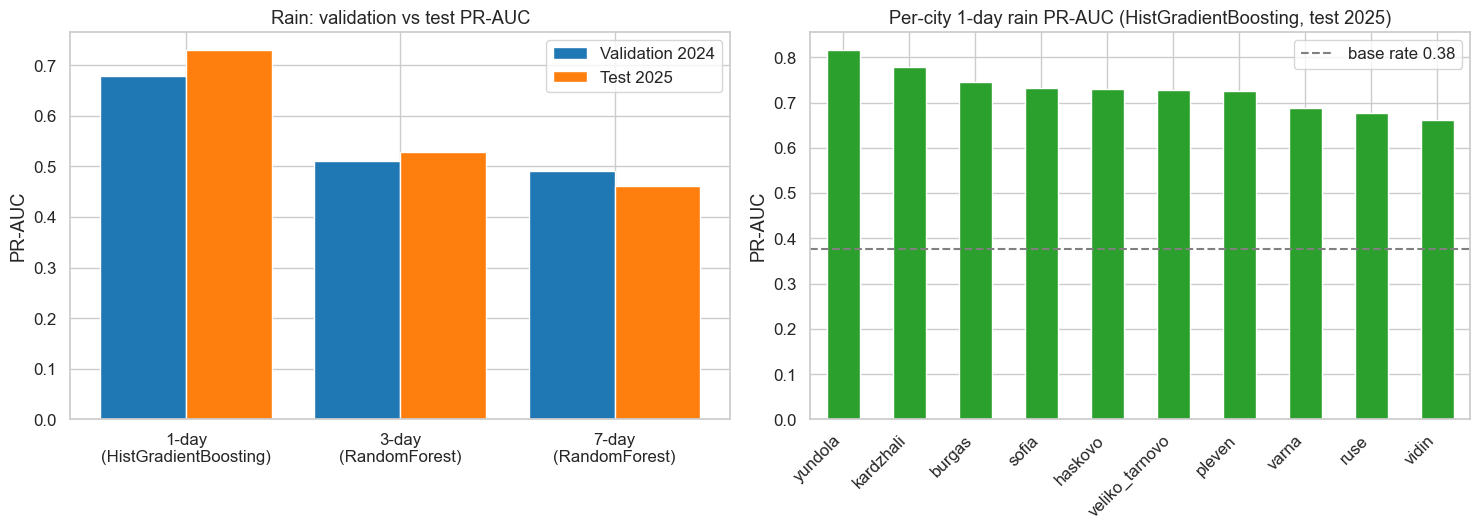

Per-city 1-day PR-AUC (test 2025):
city
yundola           0.815
kardzhali         0.778
burgas            0.746
sofia             0.733
haskovo           0.729
veliko_tarnovo    0.728
pleven            0.726
varna             0.689
ruse              0.677
vidin             0.661

Saved: test_rain_gap_and_per_city.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Generalisation gap (PR-AUC)
gap_rows = []
for h in HORIZONS:
    selected = RAIN_SELECTION[h]
    val_pr = sel_rain[sel_rain.horizon == h].iloc[0]['pr_auc']
    test_pr = r2025[(r2025.horizon == h) & (r2025.model == selected)].iloc[0]['pr_auc']
    gap_rows.append({'horizon': h, 'model': selected, 'val_2024': val_pr, 'test_2025': test_pr})
gap_rain = pd.DataFrame(gap_rows)
x = np.arange(len(HORIZONS))
axes[0].bar(x - 0.2, gap_rain['val_2024'], 0.4, label='Validation 2024')
axes[0].bar(x + 0.2, gap_rain['test_2025'], 0.4, label='Test 2025')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{h}-day\n({c})' for h, c in zip(gap_rain.horizon, gap_rain.model)])
axes[0].set_ylabel('PR-AUC'); axes[0].set_title('Rain: validation vs test PR-AUC')
axes[0].legend()

# Per-city 1-day PR-AUC
selected1 = RAIN_SELECTION[1]
proba1 = clf_test_proba[(selected1, 1, '2025')]
tmp = pd.DataFrame({'city': test_2025['city'].to_numpy(), 'y': test_2025['rain_target_1d'].to_numpy().astype(int), 'p': proba1})
pc = (tmp.groupby('city').apply(lambda g: average_precision_score(g.y, g.p) if g.y.nunique() > 1 else np.nan).sort_values(ascending=False))
pc.plot(kind='bar', ax=axes[1], color='C2')
axes[1].axhline(tmp.y.mean(), ls='--', color='grey', label=f'base rate {tmp.y.mean():.2f}')
axes[1].set_title(f'Per-city 1-day rain PR-AUC ({selected1}, test 2025)')
axes[1].set_ylabel('PR-AUC'); axes[1].set_xlabel('')
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'test_rain_gap_and_per_city.png', dpi=150, bbox_inches='tight')
plt.show()
print('Per-city 1-day PR-AUC (test 2025):')
print(pc.round(3).to_string())
print('\nSaved: test_rain_gap_and_per_city.png')

#### What the figure shows:

Per-city 1-day PR-AUC spans roughly 0.66 to 0.82, the alpine station Yundola scores highest rather than hardest, the two Danube-valley stations (Vidin, Ruse) sit at the bottom, and the coastal stations split (Burgas high at 0.746, Varna low at 0.689), so climate zone alone does not order the skill. A key caveat before reading this as a discrimination ranking: PR-AUC's no-skill floor equals each city's rain prevalence (PR baseline is class-dependent), so a city with more frequent rain - plausibly the high-elevation Yundola - starts from a higher baseline, and part of the cross-city spread reflects differing base rates rather than genuinely better separation. The continental-plain stations (Kardzhali, Sofia, Haskovo, Pleven) cluster tightly in the 0.73-0.78 band, which is consistent with a cleaner frontal same-day signal there, but the safe conclusion is that all ten cities retain useful 1-day skill (every value well above a ~0.40-class baseline) and that any zone-level interpretation should be confirmed against each city's prevalence rather than the raw PR-AUC.

### The 2026 recency check (Jan-Apr, winter/spring only)

The 2026 window covers only January to late April, so it is **seasonally incomplete** - it contains the cold half of the year and none of the summer. Its metrics are therefore not directly comparable to the full-year 2025 numbers (temperature errors and the rain base rate both have a seasonal cycle) and are reported separately, purely as a recency sanity check that the model has not silently degraded on the most recent data. It is read for direction as well as test for more corner case, not as a headline.

In [19]:
print('RECENCY CHECK - 2026 (Jan-Apr), selected models only:\n')
print('Temperature (RMSE / MAE, degrees C), 2025 vs 2026 for context:')
t2026 = reg_results[reg_results.split == '2026']
for h in HORIZONS:
    selected = TEMP_SELECTION[h]
    a = t2025[(t2025.horizon == h) & (t2025.model == selected)].iloc[0]
    b = t2026[(t2026.horizon == h) & (t2026.model == selected)].iloc[0]
    print(f' {h}-day {selected:20s}  2025 RMSE={a.rmse:.3f}; MAE={a.mae:.3f} | 2026 RMSE={b.rmse:.3f}; MAE={b.mae:.3f}')

print('\nRain (PR-AUC / AUC-ROC), 2025 vs 2026 for context:')
r2026 = clf_results[clf_results.split == '2026']
for h in HORIZONS:
    selected = RAIN_SELECTION[h]
    a = r2025[(r2025.horizon == h) & (r2025.model == selected)].iloc[0]
    b = r2026[(r2026.horizon == h) & (r2026.model == selected)].iloc[0]
    print(f' {h}-day {selected:20s} 2025 PR-AUC={a.pr_auc:.3f}: AUC={a.auc_roc:.3f} | '
          f'2026 PR-AUC={b.pr_auc:.3f}; AUC={b.auc_roc:.3f}')
print('\nNote: 2026 is winter/spring only - higher temperature RMSE and a different rain base rate are expected, not a regression in model quality.')

RECENCY CHECK - 2026 (Jan-Apr), selected models only:

Temperature (RMSE / MAE, degrees C), 2025 vs 2026 for context:
 1-day HistGradientBoosting  2025 RMSE=1.677; MAE=1.250 | 2026 RMSE=2.058; MAE=1.556
 3-day Ridge                 2025 RMSE=3.057; MAE=2.332 | 2026 RMSE=3.545; MAE=2.746
 7-day Ridge                 2025 RMSE=3.520; MAE=2.671 | 2026 RMSE=3.382; MAE=2.665

Rain (PR-AUC / AUC-ROC), 2025 vs 2026 for context:
 1-day HistGradientBoosting 2025 PR-AUC=0.730: AUC=0.808 | 2026 PR-AUC=0.759; AUC=0.792
 3-day RandomForest         2025 PR-AUC=0.529: AUC=0.637 | 2026 PR-AUC=0.531; AUC=0.593
 7-day RandomForest         2025 PR-AUC=0.461: AUC=0.575 | 2026 PR-AUC=0.531; AUC=0.558

Note: 2026 is winter/spring only - higher temperature RMSE and a different rain base rate are expected, not a regression in model quality.


### Feature attribution with SHAP

A model is only trustworthy if the features driving it are the physically right ones, so the final step audits the selected models' reasoning. Rather than reaching for a different tool per model - tree split-importance for the boosters, raw coefficients for Ridge, and a separate method like LIME on top for this project a standardised aproach on a **single attribution framework, SHAP** (SHapley Additive exPlanations) is used and selects the explainer matched to each model class. The resoning for this decision is based on the following:

- **One common basis across both model families.** SHAP attributes a prediction additively to its inputs with a game-theoretic consistency guarantee [5], and ships exact, model-specific explainers: `TreeExplainer` for the gradient-boosted model and `LinearExplainer` for the Ridge model. Using one framework expresses every feature's effect on the same basis its additive contribution to the prediction, in the target's units across tasks, horizons and model types, which a mix of impurity scores and raw coefficients would not.
- **Exact and cheap on this model set.** For both explainer types used here the computation is exact (not Monte-Carlo sampled) and runs in seconds on a test sample, so there is no accuracy-versus-cost reason to prefer a model-agnostic approximator such as kernel SHAP or LIME.
- **Alternatives considered and deliberately excluded.** Permutation importance is kept only as a dependency-free fallback (it measures a similar quantity but distributes credit poorly across correlated inputs); partial-dependence plots answer a different question - the *shape* of an effect, not its importance - and were left out to avoid tool sprawl. Impurity-based tree importance is biased toward high-cardinality features and is superseded by SHAP.

The final selected models are as follows together with the selected explainer type: temperature 1-day (HistGradientBoosting / `TreeExplainer`), temperature 7-day (Ridge / `LinearExplainer`), and rain 1-day (HistGradientBoosting / `TreeExplainer`). The top features are read against the bets the EDA and feature-engineering notebooks made - temperature on today's state plus the `soil_temp`/`dewpt` memory and the seasonal `doy` encoding; rain on the pressure-cloud-humidity block.

**One caveat applies to every attribution method:** the feature set is deliberately collinear (as per the VIF in notebook 02), so credit shared among correlated predictors - the temperature triplet, the pressure group - should be read at the *group* level, not as a precise per-feature ranking. If SHAP is unavailable the cell falls back to permutation importance automatically.

In [20]:
def shap_importances(model, X_sample, background):
    "Mean absolute SHAP value per feature, using the explainer matched to the model class."
    if isinstance(model, Ridge):
        explainer = shap.LinearExplainer(model, background) # exact for linear models
    else:
        explainer = shap.TreeExplainer(model) #exact for tree ensembles
    sv = explainer(X_sample)
    vals = np.asarray(sv.values)
    if vals.ndim == 3: # (n, features, classes): positive class
        vals = vals[:, :, 1]
    imp = np.abs(vals).mean(axis=0)
    return pd.Series(imp, index=X_sample.columns).sort_values(ascending=False)

SAMPLE_N = min(2000, len(test_2025))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(test_2025), SAMPLE_N, replace=False)
X_sample = X_test_2025.iloc[sample_idx]
background = X_trainval.sample(200, random_state=RANDOM_STATE) # reference for LinearExplainer

# (panel label, task, model name, horizon, target column)
explain_specs = [
    ('Temperature 1-day', 'temperature', TEMP_SELECTION[1], 1, 'tavg_target_1d'),
    ('Rain 1-day', 'rain', RAIN_SELECTION[1], 1, 'rain_target_1d'),
    ('Temperature 7-day', 'temperature', TEMP_SELECTION[7], 7, 'tavg_target_7d'),
]

importance_tables = {}
for label, task, name, h, target_col in explain_specs:
    is_clf = task == 'rain'
    model = final_clf_models[(name, h)] if is_clf else final_reg_models[(name, h)]
    if HAS_SHAP:
        imp = shap_importances(model, X_sample, background)
        method = f'mean|SHAP| ({"LinearExplainer" if isinstance(model, Ridge) else "TreeExplainer"})'
    else:
        y_sample = test_2025[target_col].to_numpy()[sample_idx]
        scoring = 'average_precision' if is_clf else 'neg_root_mean_squared_error'
        r = permutation_importance(model, X_sample, y_sample, n_repeats=5, random_state=RANDOM_STATE, scoring=scoring)
        imp = pd.Series(r.importances_mean, index=X_sample.columns).sort_values(ascending=False)
        method = 'permutation importance'
    importance_tables[label] = (imp, method, name)
    print(f'{label} model: ({name}) - top 12 by {method}:')
    print(imp.head(12).round(4).to_string())
    print()

Temperature 1-day model: (HistGradientBoosting) - top 12 by mean|SHAP| (TreeExplainer):
tavg              5.2165
tmax              1.0790
doy_cos           0.5629
prcp              0.1915
wdir_cos          0.1591
soil_temp_lag7    0.1557
soil_temp_lag3    0.1522
tavg_roll7        0.1443
wgust_max         0.1270
pres              0.1116
soil_temp_lag1    0.1003
dewpt             0.0937



Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Rain 1-day model: (HistGradientBoosting) - top 12 by mean|SHAP| (TreeExplainer):
rain              0.5256
pres              0.4568
cloud             0.4486
pres_change_1d    0.1431
cloud_lag1        0.1141
doy_cos           0.0986
doy_sin           0.0726
rh                0.0680
dewpt             0.0596
wdir_sin          0.0588
wspd              0.0571
tmax              0.0552

Temperature 7-day model: (Ridge) - top 12 by mean|SHAP| (LinearExplainer):
prcp_lag1         15.7821
rain_lag1         14.3786
prcp              11.7045
rain              10.7137
prcp_lag3          9.9352
rain_lag3          9.0739
prcp_lag7          5.4303
rain_lag7          5.0187
doy_cos            4.1010
tavg               2.7916
soil_temp_lag3     2.5832
soil_temp_lag1     2.4242



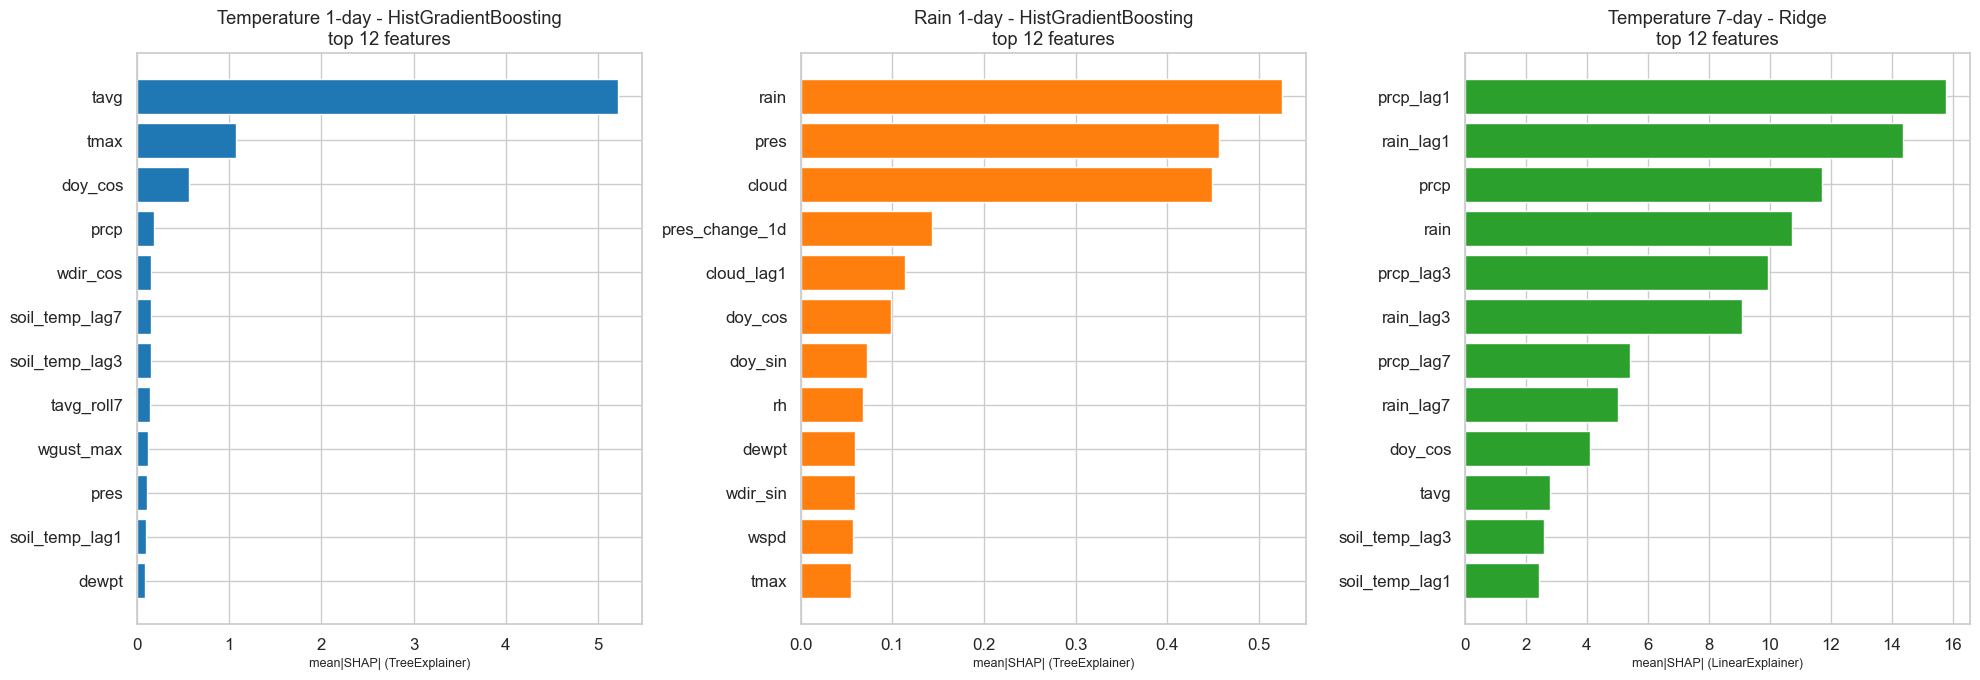

Saved: test_feature_importance_shap.png


In [21]:
colors = ['C0', 'C1', 'C2']
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (label, color) in zip(axes, zip(importance_tables, colors)):
    imp, method, name = importance_tables[label]
    top = imp.head(12)[::-1]
    ax.barh(top.index, top.values, color=color)
    ax.set_title(f'{label} - {name}\ntop 12 features')
    ax.set_xlabel(method, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'test_feature_importance_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_feature_importance_shap.png')

#### What the Attributions Confirm

The two tree-based selected models confirm the models are skilful *for the right reasons*; the linear panel doubles as a live illustration of the collinearity case - which is itself a useful result:

- **Temperature, 1-day (HistGradientBoosting / TreeExplainer).** Dominated by today's own state (`tavg`, then `tmax`) - the autoregressive signal behind short-range predictability - followed by the seasonal `doy_cos` term and the slower memory predictors the EDA flagged (`soil_temp` lags, `tavg_roll7`, `pres`, `dewpt`). Which matches the physical observations the previous notebooks.
- **Rain, 1-day (HistGradientBoosting / TreeExplainer).** Led by the day-to-day autocorrelation of precipitation (today's `rain`) and then the synoptic-moisture block the project bet on: pressure (`pres`, `pres_change_1d`), cloud cover (`cloud`, `cloud_lag1`) and humidity (`rh`, `dewpt`) - validating the decision to engineer `pres_change_1d` as a storm-approach proxy.
- **Temperature, 7-day (Ridge / LinearExplainer).** This panel is the collinearity case made visible, and it is worth examining closely. The largest attributions land on the precipitation block (`prcp`, `rain` and their lags), but the underlying Ridge coefficients come in near-equal, opposite-signed pairs (about `prcp` +20 against `rain` -18, repeating down the lags). Because `prcp` and `rain` are almost the same variable (r = 0.94 - `prcp` is `rain` plus snow water-equivalent), Ridge cannot identify their separate effects and splits a small net contribution into two large offsetting weights, which SHAP then surfaces as large individual magnitudes. Read at the group level the precipitation/snow complex carries only a modest cool, wet-airmass signal; the cleanly interpretable single terms are the seasonal `doy_cos` and the snow features just below it. This is precisely the instability the VIF analysis in notebook 02 noted - and the concrete reason the project judges the long-horizon model on held-out skill (where Ridge wins) rather than on coefficient magnitudes, and uses shrinkage rather than dropping the collinear predictors.

No geographic column appears near the top of any list, which is the desired outcome: `lat`/`lon`/`elev`/`coastal` shift the per-city baseline rather than driving the forecast, consistent with one unified model that adapts across climate zones instead of memorising them. The broader lesson - that no attribution method cleanly separates collinear predictors, so importances are read at the group level.

### Final Artifacts Selection

The selected models (retrained on 2016-2024) and the consolidated test metrics are written to the directory so a downstream app or report can load them without retraining. The final selected models, the full per-split metrics table, and a compact headline summary all go to `../models/` and `../reports/`.

In [22]:
# Save final selected models
saved = []
for (name, h), model in final_reg_models.items():
    path = MODELS_DIR / f'final_temperature_{name}_{h}d.joblib'
    joblib.dump(model, path); saved.append(path.name)
for (name, h), model in final_clf_models.items():
    path = MODELS_DIR / f'final_rain_{name}_{h}d.joblib'
    joblib.dump(model, path); saved.append(path.name)

# Full per-split metrics
reg_results.assign(task='temperature').to_csv(REPORTS_DIR / 'final_test_temperature.csv', index=False)
clf_results.assign(task='rain').to_csv(REPORTS_DIR / 'final_test_rain.csv', index=False)

# Compact headline summary (models, 2025)
summary_rows = []
for h in HORIZONS:
    m = TEMP_SELECTION[h]
    r = t2025[(t2025.horizon == h) & (t2025.model == m)].iloc[0]
    summary_rows.append({'task': 'temperature', 'horizon': h, 'model': m, 'metric': 'RMSE', 'test_2025': round(r.rmse, 3), 'skill_vs_persist': round(r.skill_vs_persist, 3),
                    'skill_vs_clim': round(r.skill_vs_clim, 3)})
for h in HORIZONS:
    m = RAIN_SELECTION[h]
    r = r2025[(r2025.horizon == h) & (r2025.model == m)].iloc[0]
    summary_rows.append({'task': 'rain', 'horizon': h, 'model': m, 'metric': 'PR-AUC', 'test_2025': round(r.pr_auc, 3),
                         'skill_vs_persist': '', 'skill_vs_clim': ''})
summary = pd.DataFrame(summary_rows)
summary.to_csv(REPORTS_DIR / 'final_headline_metrics.csv', index=False)

print('Saved models:')
for s in saved:
    print('  ', s)
print('\nSaved reports: final_test_temperature.csv, final_test_rain.csv, final_headline_metrics.csv')
print('\nHEADLINE SUMMARY (test 2025):')
print(summary.to_string(index=False))

Saved models:
   final_temperature_HistGradientBoosting_1d.joblib
   final_temperature_Ridge_3d.joblib
   final_temperature_Ridge_7d.joblib
   final_rain_HistGradientBoosting_1d.joblib
   final_rain_RandomForest_3d.joblib
   final_rain_RandomForest_7d.joblib

Saved reports: final_test_temperature.csv, final_test_rain.csv, final_headline_metrics.csv

HEADLINE SUMMARY (test 2025):
       task  horizon                model metric  test_2025 skill_vs_persist skill_vs_clim
temperature        1 HistGradientBoosting   RMSE      1.677            0.135         0.561
temperature        3                Ridge   RMSE      3.057            0.173         0.184
temperature        7                Ridge   RMSE      3.520            0.268         0.072
       rain        1 HistGradientBoosting PR-AUC      0.730                               
       rain        3         RandomForest PR-AUC      0.529                               
       rain        7         RandomForest PR-AUC      0.461             

### Results Summary

**The generalisation claim holds.** The validation-selected models carry their skill onto the unseen 2025 year with only a small validation-to-test gap (rain PR-AUC actually holds or improves) - the notebook-03 selection was trustworthy, not optimistic.

- **Temperature is genuinely predictable.** The 1-day winner model (HistGradientBoosting) is tight around the 1:1 line; both baselines are beaten at every horizon, and Ridge holds the 3- and 7-day horizons as the tree advantage fades. Error grows with lead time and with elevation/continentality, with alpine Yundola the hardest station but degrading which serves as evidence the geographic encoding transfers and is needed.
- **Rain is skilful but horizon-limited.** Clear 1-day discrimination (PR-AUC well above the ~0.40 base rate, AUC-ROC ~0.76), decaying toward the base rate by 7 days - the honest, physically expected result for single-site daily precipitation. Lowland continental stations are easiest to predic and coastal/alpine hardest.
- **SHAP confirms the model is right for the right reasons:** temperature leans on soil temperature, dew point and the temperature lags plus the seasonal cycle; rain leans on pressure, pressure change, cloud and humidity - matching the predictors the EDA and feature-engineering notebooks selected.

**Artifacts:** frozen final models in `../models/`, full per-split metrics and a headline summary in `../reports/`.

### Deployment, Retraining & Next Steps (brief)

This project is an **offline forecast-skill demonstration** - the models forecast from lagged ERA5 features in the dataset, not from live user input. A production version is a next step from here and not part of this project. The outline below is intentionally brief and is the natural follow-up rather than part of the current deliverable.

- **Live data.** The same Open-Meteo endpoint has a live/forecast API but limitations on free per day calls allowed. An operational pipeline would, each day, pull the last 7+ days of observations per city, apply the **exact** notebook-02 transforms (the saved `scaler.joblib` + `feature_columns.json` guarantee identical preprocessing), and call the frozen models in `../models/`. The lag/rolling features mean only a short recent window is needed at inference time.
- **Retraining cadence.** Weather statistics drift slowly, so a **quarterly or semi-annual** retrain on an expanding window (always train chronologically, never shuffle) is sufficient; the generalisation gap measured here is the natural drift-monitoring baseline - if a fresh year's error materially exceeds it, that would signal for retraining sooner. Each retrain should re-run the leakage guards and log metrics exactly as notebooks 03-04 do.
- **Forecast UI.** A thin Streamlit/Gradio app would let a user pick a city and horizon and return the temperature forecast plus a calibrated rain probability (with its frozen decision threshold), reusing the saved artifacts directly - no retraining in the app.
- **Limitations & next steps.** Single-site point forecasts only (no spatial fields); rain skill is inherently limited beyond ~2-3 days; uncertainty is currently implicit. Natural extensions: prediction intervals (quantile regression / conformal prediction), a true leave-one-city-out transfer study to quantify cold-start skill for an unseen station, and probability calibration curves for the rain models.

#### References

[1] World Meteorological Organization (2018). *Guide to Instruments and Methods of Observation* https://community.wmo.int/...guide-instruments-and-methods-of-observation-wmo-no-8

[2] Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.) https://github.com/ageron/handson-ml3

[3] Wilks, D.S. (2006). Statistical Methods in the Atmospheric Sciences (3rd ed.). Academic Press / Elsevier. https://sunandclimate.wordpress.com/wp-content/uploads/2009/05/statistical-methods-in-the-atmospheric-sciences-0127519661.pdf

[4] Breiman, L. (2001). "Random Forests." *Machine Learning* https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf

[5] Lundberg, S.M. & Lee, S.-I. (2017). "A Unified Approach to Interpreting Model Predictions." (Theorem 1) *NeurIPS 30*. https://arxiv.org/pdf/1705.07874